# Modélisation et optimisation

## Objectif

Cette partie du projet consiste à entraîner et comparer plusieurs modèles de Machine Learning afin de prédire le churn des clients.

Les modèles étudiés sont :

- Régression Logistique
- Arbre de Décision
- Random Forest

Les performances seront évaluées à l'aide de plusieurs métriques afin de sélectionner le modèle le plus adapté au contexte métier.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [23]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/telco_customer_churn_clean.csv"
)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [25]:
df = pd.read_csv("../data/raw/telco-customer-churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
# Conversion en chaîne de caractères puis suppression des espaces
df["TotalCharges"] = df["TotalCharges"].astype(str).str.strip()

# Conversion en numérique
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Remplacement des valeurs manquantes par 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(df["TotalCharges"].dtype)
print("Valeurs manquantes :", df["TotalCharges"].isna().sum())

float64
Valeurs manquantes : 0


In [27]:
# Variable cible
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Variables explicatives
X = df.drop(columns=["customerID", "Churn"])

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (7043, 19)
Dimensions de y : (7043,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (5634, 19)
X_test  : (1409, 19)
y_train : (5634,)
y_test  : (1409,)


In [29]:
# Variables numériques
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Variables catégorielles
categorical_features = [
    "SeniorCitizen",
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [30]:
# Transformation des variables numériques
numerical_transformer = StandardScaler()

# Transformation des variables catégorielles
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    drop="first"
)

# Preprocessor complet
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [31]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Dimensions après preprocessing :")
print("X_train :", X_train_processed.shape)
print("X_test  :", X_test_processed.shape)

Dimensions après preprocessing :
X_train : (5634, 30)
X_test  : (1409, 30)


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [33]:
# Création du modèle
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Entraînement
logistic_model.fit(X_train_processed, y_train)

# Prédictions
y_pred_logistic = logistic_model.predict(X_test_processed)

# Probabilités de churn
y_proba_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]

In [34]:
print("=== RÉSULTATS : RÉGRESSION LOGISTIQUE ===\n")

print(f"Accuracy  : {accuracy_score(y_test, y_pred_logistic):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_logistic):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_logistic):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_logistic):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_logistic):.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_logistic))

=== RÉSULTATS : RÉGRESSION LOGISTIQUE ===

Accuracy  : 0.8062
Precision : 0.6593
Recall    : 0.5588
F1-score  : 0.6049
ROC-AUC   : 0.8422

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [35]:
from sklearn.tree import DecisionTreeClassifier

# Création du modèle
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Entraînement
decision_tree_model.fit(X_train_processed, y_train)

# Prédictions
y_pred_tree = decision_tree_model.predict(X_test_processed)

# Probabilités
y_proba_tree = decision_tree_model.predict_proba(X_test_processed)[:, 1]

In [36]:
print("=== RÉSULTATS : DECISION TREE ===\n")

print(f"Accuracy  : {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_tree):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_tree):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_tree):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_tree):.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_tree))

=== RÉSULTATS : DECISION TREE ===

Accuracy  : 0.7303
Precision : 0.4917
Recall    : 0.4759
F1-score  : 0.4837
ROC-AUC   : 0.6486

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1035
           1       0.49      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [37]:
# Analyse de la complexité du Decision Tree

print("=== COMPLEXITÉ DU DECISION TREE ===")
print(f"Profondeur de l'arbre : {decision_tree_model.get_depth()}")
print(f"Nombre de feuilles : {decision_tree_model.get_n_leaves()}")
print(f"Nombre total de nœuds : {decision_tree_model.tree_.node_count}")

=== COMPLEXITÉ DU DECISION TREE ===
Profondeur de l'arbre : 23
Nombre de feuilles : 1096
Nombre total de nœuds : 2191


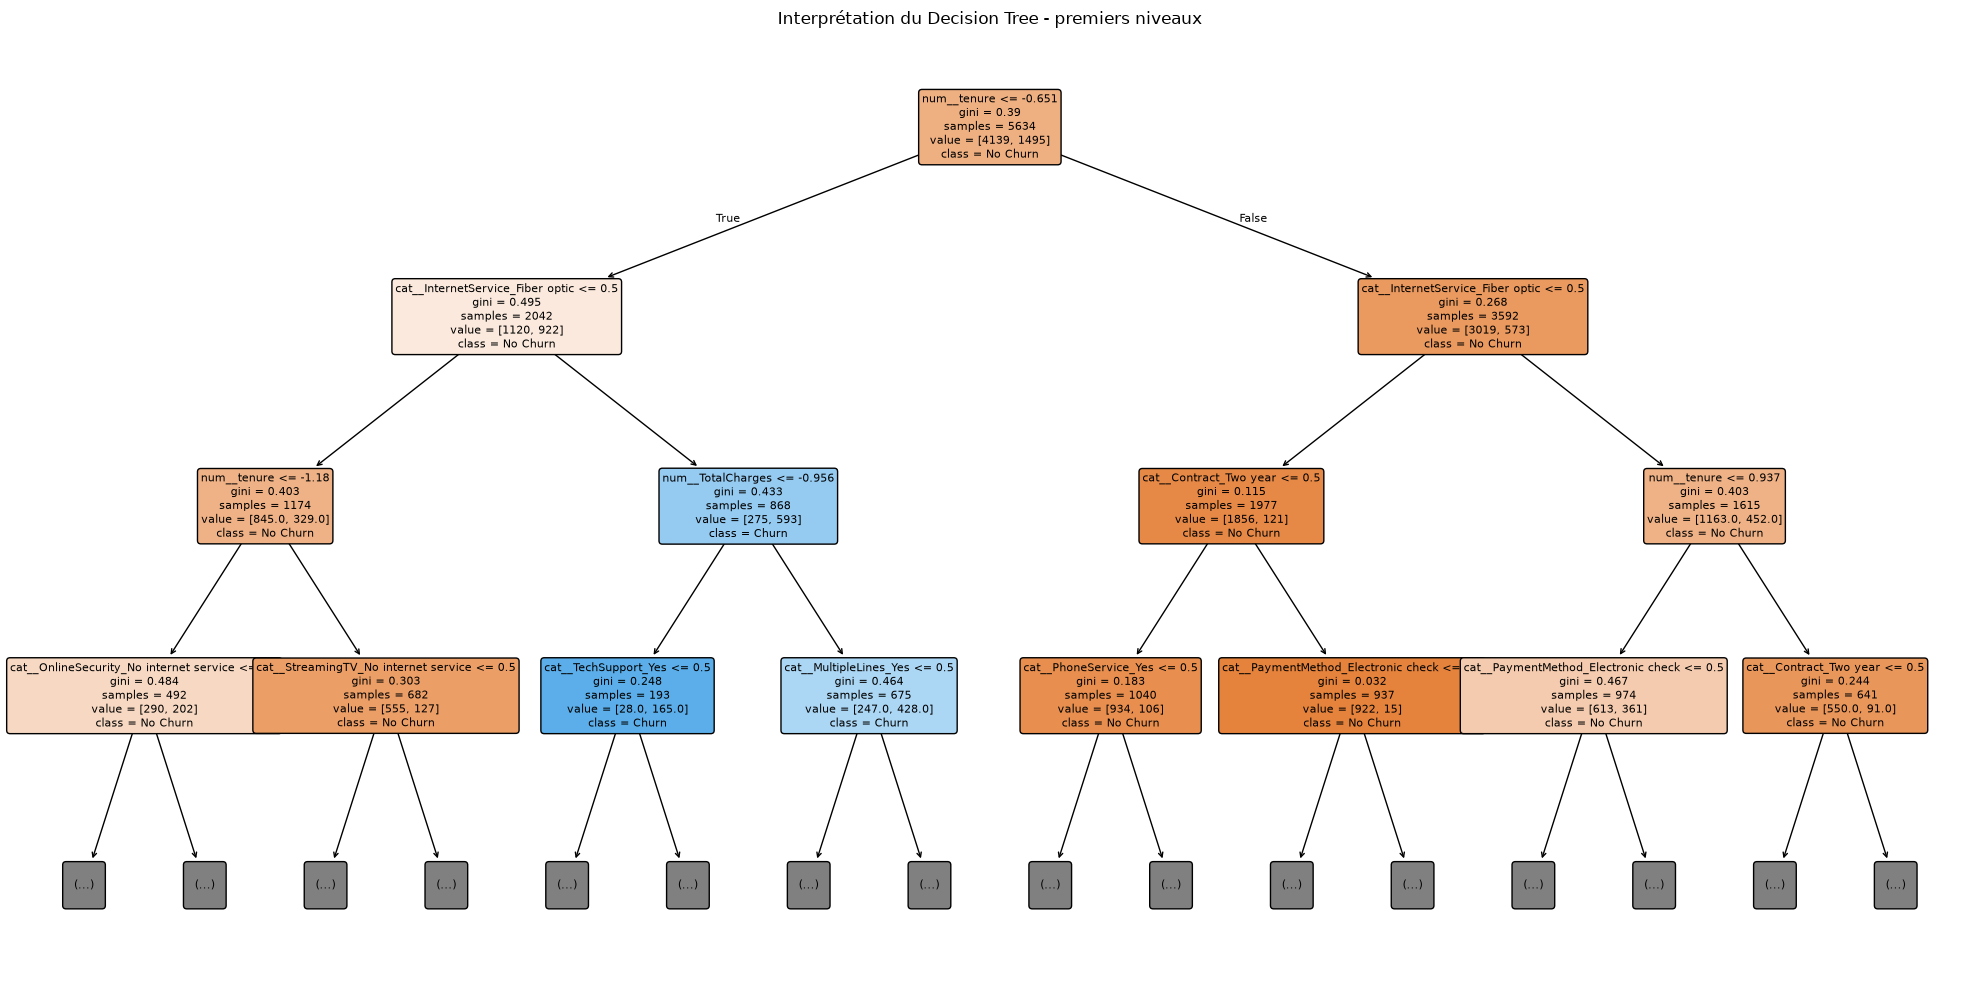

In [38]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    max_depth=3,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Interprétation du Decision Tree - premiers niveaux")
plt.tight_layout()
plt.show()

### Analyse de la complexité et interprétation du Decision Tree

Le Decision Tree obtenu sans limitation particulière permet d'observer les règles de décision utilisées pour distinguer les clients susceptibles de churner.

La profondeur de l'arbre et son nombre de feuilles permettent d'évaluer sa complexité. Un arbre trop profond peut devenir difficile à interpréter et risque davantage de surapprendre les données d'entraînement. À l'inverse, un arbre trop peu profond peut être trop simple et manquer certaines relations présentes dans les données.

Pour faciliter l'interprétation, seuls les premiers niveaux de l'arbre sont visualisés. Les variables apparaissant dans ces premiers niveaux correspondent aux critères utilisés en priorité pour séparer les clients selon leur risque de churn.

Les performances du modèle initial sont relativement faibles, avec un ROC-AUC de 0,6486 et un F1-score de 0,4837. L'optimisation des hyperparamètres est donc nécessaire afin de contrôler la complexité de l'arbre et d'améliorer sa capacité de généralisation.

In [39]:
from sklearn.ensemble import RandomForestClassifier

# Création du modèle
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Entraînement
random_forest_model.fit(X_train_processed, y_train)

# Prédictions
y_pred_rf = random_forest_model.predict(X_test_processed)

# Probabilités
y_proba_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

In [40]:
print("=== RÉSULTATS : RANDOM FOREST ===\n")

print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_rf):.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_rf))

=== RÉSULTATS : RANDOM FOREST ===

Accuracy  : 0.7949
Precision : 0.6441
Recall    : 0.5080
F1-score  : 0.5680
ROC-AUC   : 0.8256

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



La Régression Logistique obtient les meilleures performances parmi les trois modèles de référence, avec une accuracy de 80,62 % et un ROC-AUC de 0,8422. Elle présente également les meilleurs precision, recall et F1-score pour la classe churn.

Le Random Forest obtient des performances proches, mais légèrement inférieures. Le Decision Tree présente quant à lui des performances nettement plus faibles.

In [41]:
from sklearn.model_selection import GridSearchCV

In [42]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [43]:
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose v

In [44]:
print("Meilleurs paramètres :")
print(grid_rf.best_params_)

print("\nMeilleur ROC-AUC en validation croisée :")
print(f"{grid_rf.best_score_:.4f}")

Meilleurs paramètres :
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Meilleur ROC-AUC en validation croisée :
0.8435


In [45]:
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

In [46]:
grid_lr = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_grid_lr,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_lr.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informatio

In [47]:
print("Meilleurs paramètres :")
print(grid_lr.best_params_)

print("\nMeilleur ROC-AUC en validation croisée :")
print(f"{grid_lr.best_score_:.4f}")

Meilleurs paramètres :
{'C': 10, 'solver': 'lbfgs'}

Meilleur ROC-AUC en validation croisée :
0.8460


In [48]:
param_grid_tree = {
    "max_depth": [3, 5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10]
}

In [49]:
grid_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=param_grid_tree,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_tree.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [50]:
print("Meilleurs paramètres :")
print(grid_tree.best_params_)

print("\nMeilleur ROC-AUC en validation croisée :")
print(f"{grid_tree.best_score_:.4f}")

Meilleurs paramètres :
{'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}

Meilleur ROC-AUC en validation croisée :
0.8184


In [51]:
best_logistic = grid_lr.best_estimator_
best_tree = grid_tree.best_estimator_
best_rf = grid_rf.best_estimator_

In [52]:
models = {
    "Régression Logistique": best_logistic,
    "Decision Tree": best_tree,
    "Random Forest": best_rf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Régression Logistique,0.8055,0.6572,0.5588,0.6040,0.8413
1,Decision Tree,0.7956,0.6335,0.5455,0.5862,0.8270
2,Random Forest,0.8041,0.6667,0.5241,0.5868,0.8438


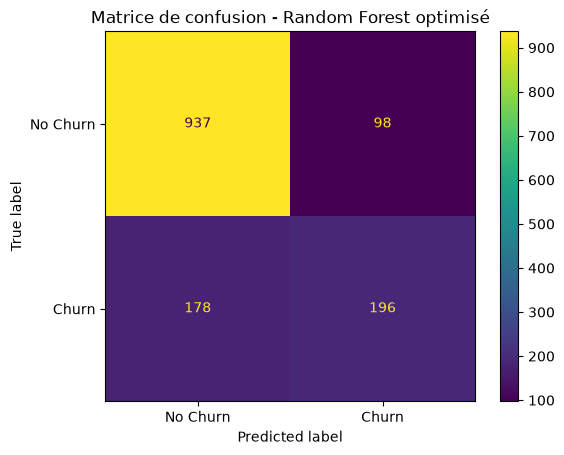

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prédictions du meilleur modèle
y_pred_final = best_rf.predict(X_test_processed)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Matrice de confusion - Random Forest optimisé")
plt.show()

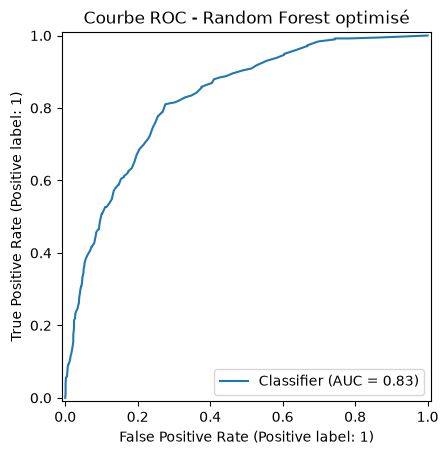

In [54]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_rf
)

plt.title("Courbe ROC - Random Forest optimisé")
plt.show()

In [55]:
feature_names = preprocessor.get_feature_names_out()

print("Nombre de variables :", len(feature_names))

Nombre de variables : 30


In [56]:
feature_importance = pd.DataFrame({
    "Variable": feature_names,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Variable,Importance
0,num__tenure,0.198270
2,num__TotalCharges,0.153570
1,num__MonthlyCharges,0.115786
10,cat__InternetService_Fiber optic,0.070254
28,cat__PaymentMethod_Electronic check,0.065558
25,cat__Contract_Two year,0.059497
24,cat__Contract_One year,0.034083
13,cat__OnlineSecurity_Yes,0.033903
19,cat__TechSupport_Yes,0.025335
26,cat__PaperlessBilling_Yes,0.021364


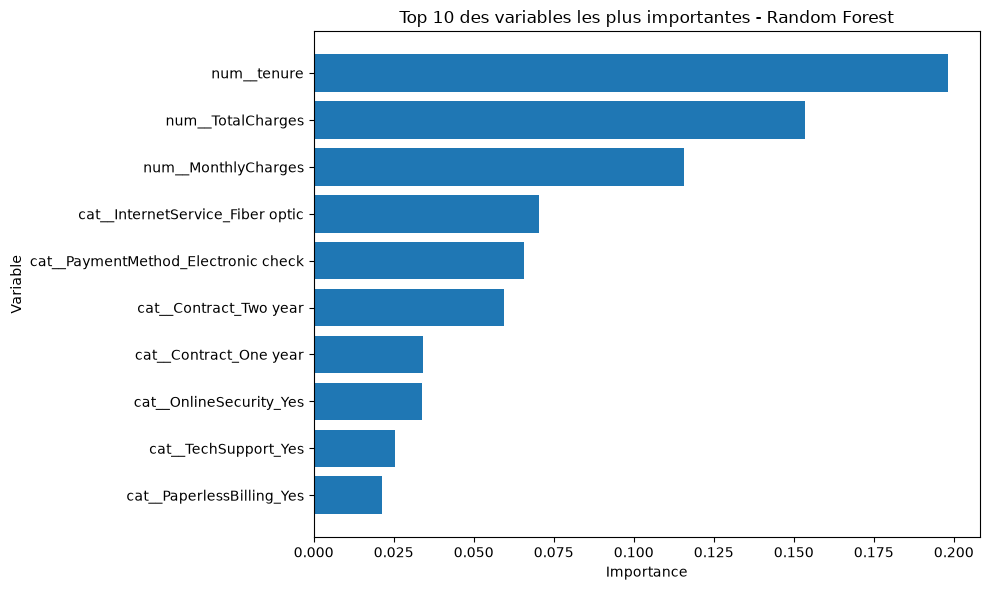

In [57]:
top_features = feature_importance.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Variable"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Top 10 des variables les plus importantes - Random Forest")

plt.tight_layout()
plt.show()

L'analyse de l'importance des variables montre que l'ancienneté (tenure), les charges totales (TotalCharges) et les charges mensuelles (MonthlyCharges) sont les variables les plus contributives aux prédictions du Random Forest. Le type de service Internet, le mode de paiement et le type de contrat jouent également un rôle important. Ces résultats indiquent des associations utiles à la prédiction, mais ne permettent pas d'établir de relations causales.